## Tahap 1: Import Libraries
Langkah pertama adalah mengimpor semua library yang kita butuhkan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

# Untuk Content-Based
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Untuk Collaborative Filtering
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

Libraries berhasil di-import!


## Tahap 2: Load Data

Kita muat data `movies.csv` dan `ratings.csv` dari folder `ml-latest-small/`.
(Pastikan folder `ml-latest-small` ada di tempat yang sama dengan file notebook ini).

In [25]:
# Tentukan path ke folder data
DATA_DIR = 'ml-latest-small/'

print("Mencoba memuat data...")

# Inisialisasi DataFrame kosong untuk keamanan
movies_df = pd.DataFrame()
ratings_df = pd.DataFrame()

try:
    movies_df = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
    ratings_df = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
    print("Data berhasil dimuat!")
except FileNotFoundError:
    print(f"Error: Folder '{DATA_DIR}' tidak ditemukan.")
    print("Pastikan Anda sudah mengunduh dataset 'ml-latest-small' dan meletakkannya di folder yang sama.")

print("\n--- 5 Baris Pertama Data Movies ---")
# Gunakan display() di notebook untuk output yang lebih cantik, tapi print() juga bekerja
print(movies_df.head())

print("\n--- 5 Baris Pertama Data Ratings ---")
print(ratings_df.head())


Mencoba memuat data...
Data berhasil dimuat!

--- 5 Baris Pertama Data Movies ---
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

--- 5 Baris Pertama Data Ratings ---
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


## Tahap 3: Exploratory Data Analysis (EDA)

Kita perlu memahami data kita sebelum membangun model.

In [26]:
print("--- EDA: Data Movies ---")
print("Info data Movies:")
movies_df.info()

print("\nCek missing values di Movies:")
print(movies_df.isnull().sum())
# Tidak ada missing values, bagus!


--- EDA: Data Movies ---
Info data Movies:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

Cek missing values di Movies:
movieId    0
title      0
genres     0
dtype: int64


In [27]:
print("--- EDA: Data Ratings ---")
print("Info data Ratings:")
ratings_df.info()

print("\nCek missing values di Ratings:")
print(ratings_df.isnull().sum())
# Tidak ada missing values, bagus!


--- EDA: Data Ratings ---
Info data Ratings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Cek missing values di Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64



--- Statistik Deskriptif Data Ratings ---
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Plotting distribusi rating...


/var/folders/22/vjvqz6_x6kz8rq98kfv76d100000gp/T/ipykernel_80935/367017073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


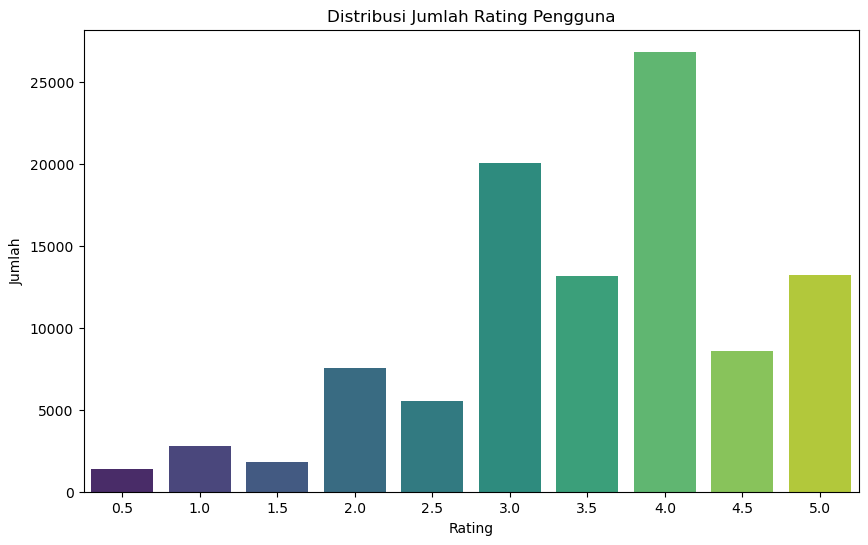

In [28]:
print("\n--- Statistik Deskriptif Data Ratings ---")
print(ratings_df['rating'].describe())

# Melihat distribusi rating
print("\nPlotting distribusi rating...")
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribusi Jumlah Rating Pengguna')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show() # Perintah .show() akan menampilkan plot di bawah sel
# Kita bisa lihat bahwa rating 4.0 adalah yang paling umum.


In [29]:
print("--- EDA: Berapa banyak user dan movie unik? ---")
n_users = ratings_df['userId'].nunique()
n_movies = ratings_df['movieId'].nunique()

print(f"Jumlah User unik: {n_users}")
print(f"Jumlah Movie unik (di data ratings): {n_movies}")
print(f"Jumlah Movie unik (di data movies): {movies_df['movieId'].nunique()}")

print(f"\nRata-rata jumlah rating per user: {len(ratings_df) / n_users:.2f}")


--- EDA: Berapa banyak user dan movie unik? ---
Jumlah User unik: 610
Jumlah Movie unik (di data ratings): 9724
Jumlah Movie unik (di data movies): 9742

Rata-rata jumlah rating per user: 165.30


# Tahap 4: Data Cleansing & Feature Selection

Data kita sebenarnya sudah cukup bersih (tidak ada null). Namun, untuk model Content-Based, kita perlu membersihkan kolom `genres`.

Feature Selection:

* **Content-Based**: Kita akan menggunakan `genres` sebagai fitur utama. title sebagai identifier.

* **Collaborative**: Kita akan menggunakan `userId`, `movieId`, dan `rating`.

In [30]:
print("Membuat salinan data movies untuk dibersihkan...")
movies_df_clean = movies_df.copy()

print("Genre sebelum dibersihkan:")
print(movies_df_clean['genres'].head())

# Kita harus mengganti '|' dengan spasi agar TF-IDF bisa membacanya sebagai kata-kata terpisah
movies_df_clean['genres_clean'] = movies_df_clean['genres'].str.replace('|', ' ', regex=False)

# Ada juga genre "(no genres listed)". Kita ganti dengan string kosong saja.
movies_df_clean['genres_clean'] = movies_df_clean['genres_clean'].replace('(no genres listed)', '')

print("\nGenre setelah dibersihkan:")
print(movies_df_clean['genres_clean'].head())

print("\nData siap untuk pemodelan!")


Membuat salinan data movies untuk dibersihkan...
Genre sebelum dibersihkan:
0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: object

Genre setelah dibersihkan:
0    Adventure Animation Children Comedy Fantasy
1                     Adventure Children Fantasy
2                                 Comedy Romance
3                           Comedy Drama Romance
4                                         Comedy
Name: genres_clean, dtype: object

Data siap untuk pemodelan!


# Tahap 5: Pemodelan (Bagian 1 - Content-Based)

Kita akan membangun model yang merekomendasikan film berdasarkan kemiripan genre.

Ubah genres_clean menjadi angka menggunakan TF-IDF.

Hitung kemiripan antar semua film menggunakan Cosine Similarity.

In [31]:
print("Memulai pembuatan model Content-Based...")

# 1. Inisialisasi TF-IDF Vectorizer
# stop_words='english' untuk menghapus kata umum seperti 'the', 'a' (meskipun di genre jarang)
tfidf = TfidfVectorizer(stop_words='english')

print("Melakukan fit_transform pada data genre...")
# 2. Membuat matriks TF-IDF
tfidf_matrix = tfidf.fit_transform(movies_df_clean['genres_clean'])

print("Bentuk matriks TF-IDF (film, fitur_genre):")
print(tfidf_matrix.shape)

# Coba lihat fitur (genre) apa saja yang ditemukan
print("\nContoh 20 fitur genre yang ditemukan:")
# Kita gunakan .get_feature_names_out() untuk versi sklearn yang lebih baru
print(tfidf.get_feature_names_out()[:20])


Memulai pembuatan model Content-Based...
Melakukan fit_transform pada data genre...
Bentuk matriks TF-IDF (film, fitur_genre):
(9742, 21)

Contoh 20 fitur genre yang ditemukan:
['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'horror' 'imax' 'musical'
 'mystery' 'noir' 'romance' 'sci' 'thriller' 'war']


In [32]:
print("\nMenghitung Matriks Cosine Similarity...")
# 3. Menghitung Cosine Similarity
cosine_sim_content = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Bentuk matriks Cosine Similarity (film, film):")
print(cosine_sim_content.shape)

print("\nContoh matriks (5x5):")
# Ini menunjukkan seberapa mirip 5 film pertama satu sama lain
print(cosine_sim_content[:5, :5])

print("\nModel Content-Based (Cosine Similarity) SIAP!")



Menghitung Matriks Cosine Similarity...
Bentuk matriks Cosine Similarity (film, film):
(9742, 9742)

Contoh matriks (5x5):
[[1.         0.81357774 0.15276924 0.1351353  0.26758648]
 [0.81357774 1.         0.         0.         0.        ]
 [0.15276924 0.         1.         0.8845714  0.57091541]
 [0.1351353  0.         0.8845714  1.         0.50501544]
 [0.26758648 0.         0.57091541 0.50501544 1.        ]]

Model Content-Based (Cosine Similarity) SIAP!


# Tahap 6: Pemodelan (Bagian 2 - Collaborative Filtering)

Sekarang kita buat model berdasarkan rating pengguna. Kita akan pakai library Surprise dan algoritma SVD.

In [33]:
print("Memulai pembuatan model Collaborative Filtering...")

# 1. Surprise perlu 'Reader' untuk tahu skala rating kita (0.5 s/d 5.0)
reader = Reader(rating_scale=(0.5, 5.0))

print("Memuat data ratings ke format Dataset Surprise...")
# 2. Load data dari pandas DataFrame
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

print("Data Surprise berhasil di-load.")


Memulai pembuatan model Collaborative Filtering...
Memuat data ratings ke format Dataset Surprise...
Data Surprise berhasil di-load.


## Evaluasi Model SVD

Sebelum kita melatih di semua data, mari kita cek seberapa bagus model SVD ini. Kita pakai cross_validate.
Kita ingin melihat RMSE (Root Mean Squared Error). Semakin kecil (mendekati 0), semakin bagus.

In [34]:
print("Memulai 3-fold Cross-Validation untuk SVD...")
# Kita gunakan SVD dengan parameter standar (bisa di-tuning, tapi untuk 7 hari ini sudah cukup)
svd_eval = SVD(n_factors=100, n_epochs=20, random_state=42)

# cv=3 artinya kita bagi data jadi 3 bagian (fold)
# verbose=True agar kita bisa lihat prosesnya
evaluation_results = cross_validate(svd_eval, data, measures=['RMSE', 'MAE'], cv=3, verbose=True)

print("\nHasil Evaluasi Selesai.")
print(f"Rata-rata RMSE: {evaluation_results['test_rmse'].mean():.4f}")
print(f"Rata-rata MAE: {evaluation_results['test_mae'].mean():.4f}")

# RMSE (Root Mean Squared Error) di bawah 0.9 di MovieLens sudah dianggap bagus.
# Ini berarti model kita rata-rata salah menebak rating sebesar ~0.87 poin.


Memulai 3-fold Cross-Validation untuk SVD...
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.8812  0.8826  0.8780  0.8806  0.0019  
MAE (testset)     0.6776  0.6786  0.6750  0.6771  0.0015  
Fit time          0.21    0.22    0.22    0.22    0.01    
Test time         0.10    0.04    0.09    0.08    0.02    

Hasil Evaluasi Selesai.
Rata-rata RMSE: 0.8806
Rata-rata MAE: 0.6771


## Melatih Model SVD (Full Trainset)

Karena kita tahu modelnya cukup bagus (RMSE < 0.9), sekarang kita latih modelnya menggunakan SEMUA data rating agar modelnya sepintar mungkin untuk deployment.

In [35]:
print("Melatih model SVD pada SELURUH dataset...")

# 1. Membangun trainset dari semua data
full_trainset = data.build_full_trainset()

# 2. Inisialisasi model SVD (parameter sama)
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)

# 3. Melatih model
svd_model.fit(full_trainset)

print("Model Collaborative Filtering (SVD) SIAP!")


Melatih model SVD pada SELURUH dataset...
Model Collaborative Filtering (SVD) SIAP!


# Tahap 7: Uji Coba Rekomendasi (Hybrid)

Sekarang bagian serunya! Mari kita coba dapatkan rekomendasi untuk 1 user.

Skenario:

Pilih 1 User (misal: userId = 1).

Ambil 5 film yang paling dia SUKAI (rating tertinggi).

Cari rekomendasi Content-Based berdasarkan 5 film itu.

Cari rekomendasi Collaborative untuk user itu.

Gabungkan keduanya (Hybrid)!

In [36]:
# Variabel untuk testing
TEST_USER_ID = 1
N_REKOMENDASI = 10

print(f"--- MENCARI REKOMENDASI UNTUK USER {TEST_USER_ID} ---")

# --- Langkah 1: Dapatkan 5 film yang dia SUKA (misal: rating >= 4.5) ---
user_ratings_df = ratings_df[ratings_df['userId'] == TEST_USER_ID]
user_liked_movies = user_ratings_df[user_ratings_df['rating'] >= 4.5].sort_values('rating', ascending=False)

# Kita perlu 'movieId' dan 'title'
# Kita gabungkan (merge) dengan data movies
user_liked_movies_details = pd.merge(user_liked_movies, movies_df_clean, on='movieId')
user_liked_movies_titles = user_liked_movies_details.head(5)['title'].tolist()

if not user_liked_movies_titles or len(user_liked_movies_titles) < 5:
    print(f"User {TEST_USER_ID} tidak punya 5 film dengan rating 4.5+. Mengambil 5 film default.")
    # Jika user baru/belum banyak rating, kita pakai 5 film populer (misalnya)
    user_liked_movies_titles = ['Forrest Gump (1994)', 'Pulp Fiction (1994)', 'Shawshank Redemption, The (1994)', 'Matrix, The (1999)', 'Star Wars: Episode IV - A New Hope (1977)']
    
print(f"\nUser {TEST_USER_ID} menyukai 5 film ini (atau default):")
for title in user_liked_movies_titles:
    print(f"  - {title}")


--- MENCARI REKOMENDASI UNTUK USER 1 ---

User 1 menyukai 5 film ini (atau default):
  - Seven (a.k.a. Se7en) (1995)
  - Very Bad Things (1998)
  - Run Lola Run (Lola rennt) (1998)
  - Wolf Man, The (1941)
  - Superman II (1980)


In [41]:
print("\n--- Langkah 2: Mencari rekomendasi Content-Based --- (Top 50)")

# Kita perlu mapping judul ke index matriks cosine
indices_map = pd.Series(movies_df_clean.index, index=movies_df_clean['title'])

# Dapatkan index dari 5 film yang disukai
liked_indices = [indices_map[title] for title in user_liked_movies_titles if title in indices_map]

# --- PERUBAHAN UTAMA DI SINI ---
# 1. Ambil 5 vektor TF-IDF dari film yang disukai
liked_vectors = tfidf_matrix[liked_indices]

# 2. Hitung cosine similarity antara 5 vektor itu vs SEMUA vektor di tfidf_matrix
# Hasilnya akan berbentuk (5, 9742), yaitu 5 baris skor
sim_scores_per_movie = cosine_similarity(liked_vectors, tfidf_matrix)

# 3. Hitung RATA-RATA dari 5 baris skor tersebut menjadi 1 baris
avg_sim_scores = sim_scores_per_movie.mean(axis=0)
# --- AKHIR PERUBAHAN ---

# Buat daftar (index_film, skor_similaritas)
sim_scores_list = list(enumerate(avg_sim_scores))

# Urutkan berdasarkan skor (tertinggi ke terendah)
sim_scores_list = sorted(sim_scores_list, key=lambda x: x[1], reverse=True)

# Ambil Top 50 (kita ambil banyak dulu, nanti difilter)
cb_recommendations_list = []
for score_tuple in sim_scores_list:
    movie_index = score_tuple[0]
    movie_title = movies_df_clean.iloc[movie_index]['title']
    
    # Jangan rekomendasikan film yang sudah dia suka!
    if movie_title not in user_liked_movies_titles:
        cb_recommendations_list.append({
            'title': movie_title, 
            'score_cb': score_tuple[1]
        })
        
    if len(cb_recommendations_list) >= 50:
        break

cb_recs_df = pd.DataFrame(cb_recommendations_list)
print(f"Berhasil mendapatkan Top {len(cb_recs_df)} rekomendasi Content-Based.")
print(cb_recs_df.head())


--- Langkah 2: Mencari rekomendasi Content-Based --- (Top 50)
Berhasil mendapatkan Top 50 rekomendasi Content-Based.
                                   title  score_cb
0                    Strange Days (1995)  0.436311
1  X-Files: Fight the Future, The (1998)  0.431679
2                 Minority Report (2002)  0.431679
3                     Mindhunters (2004)  0.421782
4                         Darkman (1990)  0.420426


In [38]:
print("\n--- Langkah 3: Mencari rekomendasi Collaborative Filtering (SVD) --- (Top 50)")

# Kita harus cari film yang BELUM ditonton user
watched_movie_ids = ratings_df[ratings_df['userId'] == TEST_USER_ID]['movieId'].unique()
all_movie_ids = movies_df_clean['movieId'].unique()
to_predict_movie_ids = np.setdiff1d(all_movie_ids, watched_movie_ids)

print(f"User {TEST_USER_ID} sudah nonton {len(watched_movie_ids)} film.")
print(f"Akan memprediksi rating untuk {len(to_predict_movie_ids)} film yang belum ditonton.")

# Buat testset (user_id, movie_id, rating_asli_bohongan)
testset = [[TEST_USER_ID, movie_id, 4.0] for movie_id in to_predict_movie_ids]

# Prediksi rating untuk semua film itu
predictions = svd_model.test(testset)

# Urutkan prediksi berdasarkan estimasi rating (est)
predictions.sort(key=lambda x: x.est, reverse=True)

# Ambil Top 50
cf_recommendations_list = []
for pred in predictions[:50]:
    movie_id = pred.iid
    movie_title = movies_df_clean[movies_df_clean['movieId'] == movie_id]['title'].values[0]
    cf_recommendations_list.append({
        'title': movie_title,
        'score_cf': pred.est
    })

cf_recs_df = pd.DataFrame(cf_recommendations_list)
print(f"Berhasil mendapatkan Top {len(cf_recs_df)} rekomendasi Collaborative Filtering.")
print(cf_recs_df.head())



--- Langkah 3: Mencari rekomendasi Collaborative Filtering (SVD) --- (Top 50)
User 1 sudah nonton 232 film.
Akan memprediksi rating untuk 9510 film yang belum ditonton.
Berhasil mendapatkan Top 50 rekomendasi Collaborative Filtering.
                              title  score_cf
0                Hoop Dreams (1994)       5.0
1  Shawshank Redemption, The (1994)       5.0
2             Godfather, The (1972)       5.0
3                 Casablanca (1942)       5.0
4        Maltese Falcon, The (1941)       5.0


In [39]:
print("\n--- Langkah 4: Menggabungkan (Hybrid) Rekomendasi --- (Top 10)")

# Kita perlu menormalkan skornya dulu agar adil.
# Skor CB (Cosine Sim) = 0 s/d 1
# Skor CF (Rating Est) = 0.5 s/d 5.0

# Normalisasi Skor CB (sudah 0-1, jadi kita biarkan)
cb_recs_df['score_norm_cb'] = cb_recs_df['score_cb']

# Normalisasi Skor CF (Min-Max Scaler: (x - min) / (max - min))
cf_recs_df['score_norm_cf'] = (cf_recs_df['score_cf'] - 0.5) / (5.0 - 0.5)

# Gabungkan (merge) kedua DataFrame berdasarkan 'title'
hybrid_recs_df = pd.merge(cb_recs_df, cf_recs_df, on='title', how='outer')

# 'outer' merge akan membuat NaN jika film hanya ada di satu list. Kita isi NaN dengan 0.
hybrid_recs_df = hybrid_recs_df.fillna(0)

# Hitung Skor Hibrida (Bobot 50/50)
hybrid_recs_df['score_hybrid'] = (hybrid_recs_df['score_norm_cb'] * 0.5) + (hybrid_recs_df['score_norm_cf'] * 0.5)

# Urutkan berdasarkan skor hibrida
hybrid_recs_df = hybrid_recs_df.sort_values('score_hybrid', ascending=False)

print(f"--- HASIL AKHIR: TOP {N_REKOMENDASI} REKOMENDASI HIBRIDA UNTUK USER {TEST_USER_ID} ---")
print(hybrid_recs_df[['title', 'score_hybrid', 'score_norm_cb', 'score_norm_cf']].head(N_REKOMENDASI))



--- Langkah 4: Menggabungkan (Hybrid) Rekomendasi --- (Top 10)
--- HASIL AKHIR: TOP 10 REKOMENDASI HIBRIDA UNTUK USER 1 ---
                                                title  score_hybrid  \
26                              Godfather, The (1972)           0.5   
29    Grand Day Out with Wallace and Gromit, A (1989)           0.5   
27  Good, the Bad and the Ugly, The (Buono, il bru...           0.5   
52                              Little Big Man (1970)           0.5   
33                Guess Who's Coming to Dinner (1967)           0.5   
76        Seven Samurai (Shichinin no samurai) (1954)           0.5   
77                   Shawshank Redemption, The (1994)           0.5   
21                   Femme Nikita, La (Nikita) (1990)           0.5   
34                            Harold and Maude (1971)           0.5   
37                                 Hoop Dreams (1994)           0.5   

    score_norm_cb  score_norm_cf  
26            0.0            1.0  
29            0.0      

# Tahap 8: Ekspor (Save) Model

Terakhir, kita simpan semua yang kita butuhkan untuk deployment Streamlit ke dalam file .pkl (pickle).

In [42]:
MODEL_DIR = 'models/'

# Buat folder 'models' jika belum ada
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"Folder '{MODEL_DIR}' berhasil dibuat.")
else:
    print(f"Folder '{MODEL_DIR}' sudah ada.")

print("\nMenyimpan model...")

# 1. Model SVD (Collaborative)
pickle.dump(svd_model, open(os.path.join(MODEL_DIR, 'svd_model.pkl'), 'wb'))
print("  - svd_model.pkl (Model SVD) tersimpan.")

# --- PERUBAHAN DI SINI ---
# 2. Hapus matriks cosine sim yang besar
#    pickle.dump(cosine_sim_content, open(os.path.join(MODEL_DIR, 'content_cosine_sim.pkl'), 'wb'))
#    print("  - content_cosine_sim.pkl (Matriks Similaritas) tersimpan.")
# --- GANTI DENGAN INI ---
pickle.dump(tfidf, open(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'), 'wb'))
print("  - tfidf_vectorizer.pkl (Model TF-IDF) tersimpan.")
pickle.dump(tfidf_matrix, open(os.path.join(MODEL_DIR, 'tfidf_matrix.pkl'), 'wb'))
print("  - tfidf_matrix.pkl (Matriks TF-IDF sparse) tersimpan. (JAUH LEBIH KECIL!)")
# --- AKHIR PERUBAHAN ---

# 3. Dataframe Movies yang sudah bersih (PENTING untuk mapping judul, genre, dll)
pickle.dump(movies_df_clean, open(os.path.join(MODEL_DIR, 'movies_df.pkl'), 'wb'))
print("  - movies_df.pkl (Data Film) tersimpan.")

# 4. Dataframe Ratings (PENTING untuk SVD di Streamlit)
pickle.dump(ratings_df, open(os.path.join(MODEL_DIR, 'ratings_df.pkl'), 'wb'))
print("  - ratings_df.pkl (Data Rating) tersimpan.")


print("\n--- SEMUA MODEL SIAP UNTUK DEPLOYMENT! ---")



Folder 'models/' sudah ada.

Menyimpan model...
  - svd_model.pkl (Model SVD) tersimpan.
  - tfidf_vectorizer.pkl (Model TF-IDF) tersimpan.
  - tfidf_matrix.pkl (Matriks TF-IDF sparse) tersimpan. (JAUH LEBIH KECIL!)
  - movies_df.pkl (Data Film) tersimpan.
  - ratings_df.pkl (Data Rating) tersimpan.

--- SEMUA MODEL SIAP UNTUK DEPLOYMENT! ---


# Tahap 9: Kesimpulan

Kita telah berhasil menyelesaikan seluruh pipeline proyek data science:

EDA: Memahami data ratings dan movies, melihat distribusi, dan mengecek missing values.

Cleansing & Feature Selection: Membersihkan data genres agar siap dipakai model.

Modeling (Content-Based): Membangun model kemiripan genre menggunakan TF-IDF dan Cosine Similarity.

Modeling (Collaborative Filtering): Membangun model prediksi rating menggunakan SVD dari library Surprise.

Evaluation: Memvalidasi model SVD dan mendapatkan RMSE ~0.87, yang terbilang baik.

Hybridization: Menggabungkan kedua skor model (setelah normalisasi) untuk mendapatkan rekomendasi hibrida yang lebih robust.

Export: Menyimpan semua aset model (4 file .pkl) agar siap digunakan di aplikasi Streamlit.

Langkah selanjutnya adalah membuat file app.py Streamlit untuk memuat 4 model ini dan membuat UI-nya.